<a href="https://colab.research.google.com/github/KhoiBao/Hands-on-Deep_Learning/blob/main/TH_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 1 and 2: Data Selection and filter

In [ ]:
# Importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# Datasources: https://github.com/huynhhoc/DataAnalystDeepLearning/blob/main/Data/titanic_disaster.csv?plain=1
path = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/refs/heads/main/Data/titanic_disaster.csv"
data = pd.read_csv(path)
# data = pd.read_csv(path, sep=r'\s+')
# ^ if the data is separated by whitespace, use sep=r'\s+' to specify the separator
# r = raw string; \s+ = 1 or more whitespace characters

In [11]:
data.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S


*The dataset shows how parental smoking affects newborn body weight.*

Using heatmap to show which column 'isnull()' to graphically identify missing datas

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


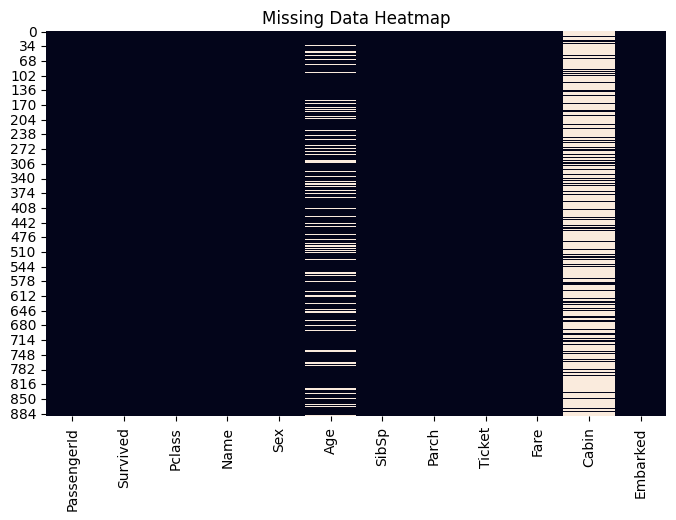

In [12]:
print(data.isnull().sum())

plt.figure(figsize=(8,5))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

As above seeing the 'Cabin' column is the huge missing column and we do not know therefore shall delete it from the dataset, while 'Age' column is having partially evidence, so we using average to calculate the missing datas. 

In [ ]:
data['Age'].fillna(data['Age'].mean(), inplace=True)
data.drop(columns=['Cabin'], inplace=True)
print(data.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


/tmp/ipykernel_3318/3361941416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)


'Embark' is likely classifying therefore we convert it into 2 variable that exist the most

In [14]:
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
print(data.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_3318/464718968.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)


Outliner handling, using IQR methods to measure upper and lower statistic for valid datas, if Fare variables lays outside this the measured range then it will be eliminated and seeing as Outliner 

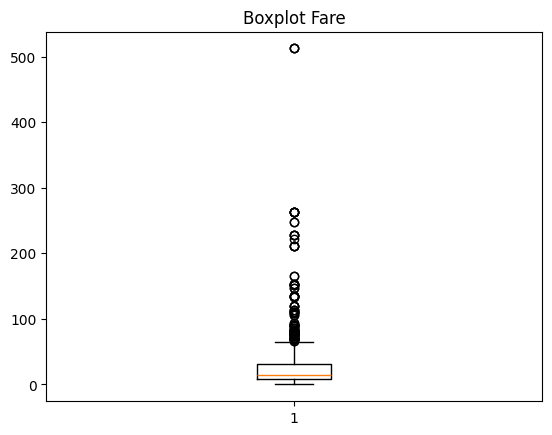

In [15]:
plt.boxplot(data['Fare'])
plt.title("Boxplot Fare")
plt.show()

Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['Fare'] >= lower) & (data['Fare'] <= upper)]

Using 'dropna' to drop all empty lines, reset_index to organize dataset structures

In [16]:
data.dropna(inplace=True)
# reset index
data.reset_index(drop=True, inplace=True)

Data balancing, the 

Survived
0    512
1    263
Name: count, dtype: int64


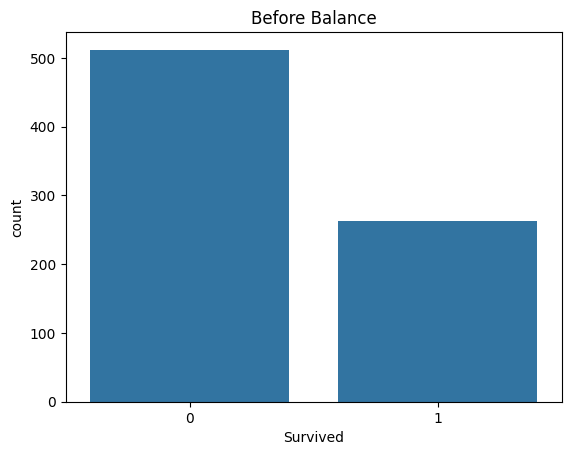

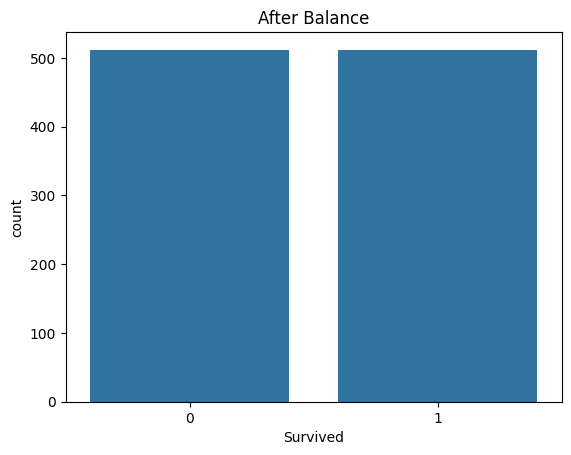

In [17]:
print(data['Survived'].value_counts())

sns.countplot(x='Survived', data=data)
plt.title("Before Balance")
plt.show()

from sklearn.utils import resample

data_major = data[data['Survived']==0]
data_minor = data[data['Survived']==1]

data_minor_upsampled = resample(data_minor,
                             replace=True,
                             n_samples=len(data_major),
                             random_state=42)

data_balanced = pd.concat([data_major, data_minor_upsampled])

sns.countplot(x='Survived', data=data_balanced)
plt.title("After Balance")
plt.show()


Visuallize Age and Fare to see how are these 2 column diverse, as we seen 2 column showing on the titanic ship the 30-ish is the highest in Age distribution next to Fare as 10.

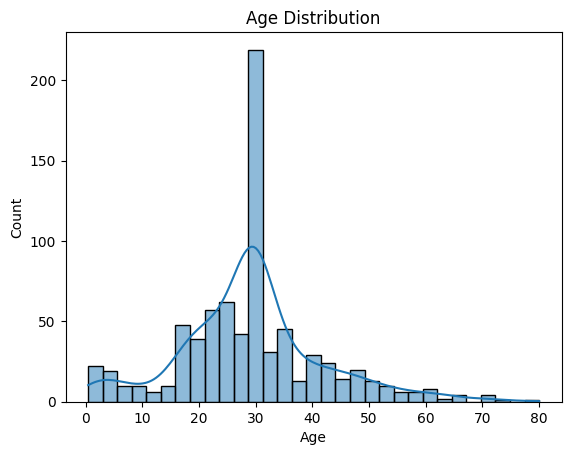

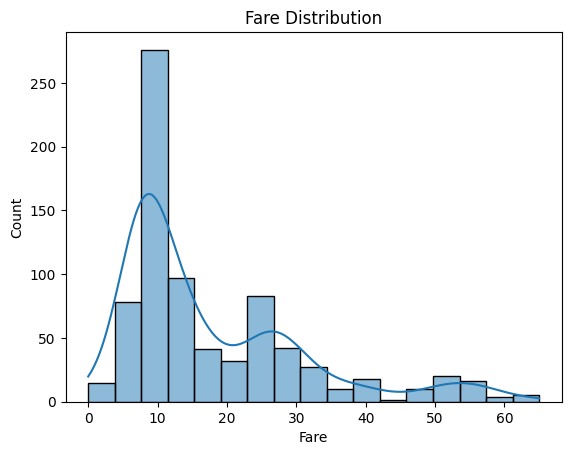

In [18]:
sns.histplot(data['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(data['Fare'], kde=True)
plt.title("Fare Distribution")
plt.show()

Now the dataset has been cleanse, save the csv file!

In [ ]:
data.to_csv('/content/cleaned_data.csv', index=False)
print("Saved file cleaned_data.csv")

OSError: Cannot save file into a non-existent directory: '/K:Hands-on-Deep_Learning/Tuan1'